In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score

FEATURE_CONFIG = {
    "sample_rate": 16000,
    "n_mfcc": 13,
    "n_fft": 512,
    "hop_length": 256,
    "win_length": 512,
    "n_mels": 40,
    "fmin": 0,
    "fmax": 8000
}

print("Feature extraction config:")
for k, v in FEATURE_CONFIG.items():
    print(f"{k}: {v}")


def extract_mfcc_features(audio_path, config):
    y, sr = librosa.load(audio_path, sr=config["sample_rate"])

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=config["n_mfcc"],
        n_fft=config["n_fft"],
        hop_length=config["hop_length"],
        win_length=config["win_length"],
        n_mels=config["n_mels"],
        fmin=config["fmin"]
    )

    mean = np.mean(mfcc, axis=1)
    std = np.std(mfcc, axis=1)
    features = np.concatenate([mean, std])

    return features


def load_data_from_folder(folder_path, config):
    X = []
    y = []

    audio_exts = (".wav", ".mp3", ".flac", ".ogg", ".m4a")

    for label in os.listdir(folder_path):
        label_path = os.path.join(folder_path, label)

        if os.path.isdir(label_path):
            for file in os.listdir(label_path):
                if file.lower().endswith(audio_exts):
                    file_path = os.path.join(label_path, file)

                    try:
                        features = extract_mfcc_features(file_path, config)
                        X.append(features)
                        y.append(label)
                    except Exception as e:
                        print(f"Skip file {file_path} because error: {e}")

    return np.array(X), np.array(y)


train_path = r"C:\Users\Hoannd\Downloads\ail\git_project\-the-adults-cried\data_fine_turn\train"
test_path  = r"C:\Users\Hoannd\Downloads\ail\git_project\-the-adults-cried\data_fine_turn\test"

x_train, y_train = load_data_from_folder(train_path, FEATURE_CONFIG)
x_test, y_test = load_data_from_folder(test_path, FEATURE_CONFIG)

le = LabelEncoder()
y_train_encoder = le.fit_transform(y_train)
y_test_encoder = le.transform(y_test)

print("\nTrain:", len(x_train))
print("Test:", len(x_test))

if len(x_train) > 0:
    print("Feature vector shape:", x_train[0].shape)
    print("Expected feature dimension:", FEATURE_CONFIG["n_mfcc"] * 2)

print("\nTrain distribution:")
print(pd.Series(y_train).value_counts())

print("\nTest distribution:")
print(pd.Series(y_test).value_counts())


def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

def plot_confusion_matrix_normal(y_true, y_pred, class_names, title="Normalized Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    # chuẩn hóa theo hàng, tránh chia cho 0
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm.astype(float), row_sums, where=row_sums != 0)

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

Feature extraction config:
sample_rate: 16000
n_mfcc: 13
n_fft: 512
hop_length: 256
win_length: 512
n_mels: 40
fmin: 0
fmax: 8000


c:\Users\Hoannd\AppData\Local\Programs\Python\Python312\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=64
  warnings.warn(



Train: 1569
Test: 283
Feature vector shape: (26,)
Expected feature dimension: 26

Train distribution:
hungry        519
burping       175
belly_pain    175
discomfort    175
lonely        175
scared        175
tired         175
Name: count, dtype: int64

Test distribution:
hungry        223
tired          18
discomfort     15
belly_pain      9
lonely          7
burping         6
scared          5
Name: count, dtype: int64


SVM

=== SVM ===
Accuracy     : 0.8163
F1 Macro     : 0.5127
Recall Macro : 0.5726

              precision    recall  f1-score   support

  belly_pain       0.38      0.67      0.48         9
     burping       0.33      0.67      0.44         6
  discomfort       0.50      0.20      0.29        15
      hungry       0.92      0.91      0.92       223
      lonely       0.44      0.57      0.50         7
      scared       0.38      0.60      0.46         5
       tired       0.70      0.39      0.50        18

    accuracy                           0.82       283
   macro avg       0.52      0.57      0.51       283
weighted avg       0.83      0.82      0.81       283



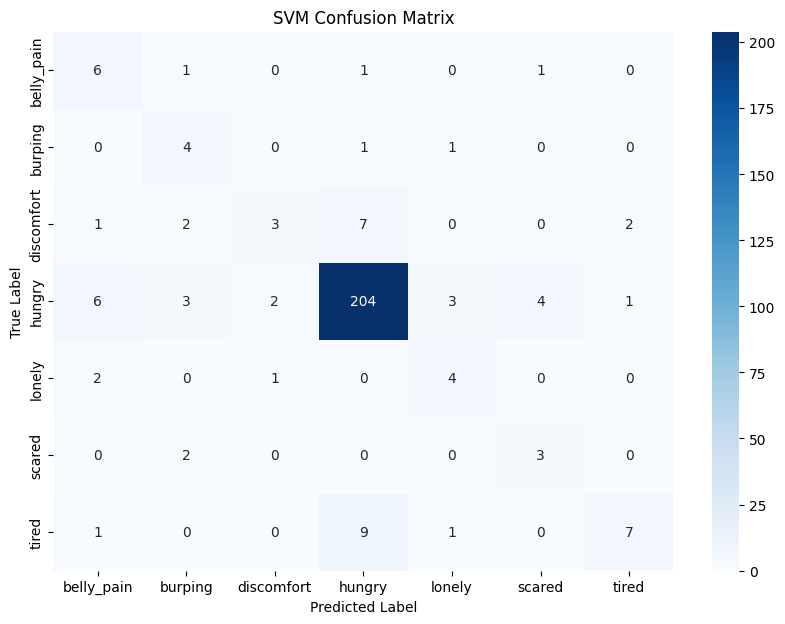

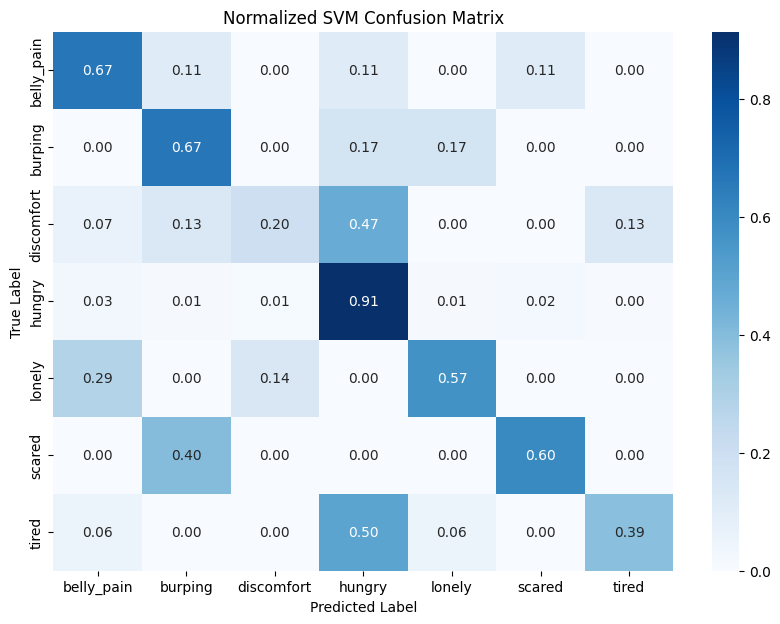

In [4]:
pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1, gamma="scale"))
])

pipeline_svm.fit(x_train, y_train_encoder)
y_pred_svm = pipeline_svm.predict(x_test)

# ===== metrics =====
acc = accuracy_score(y_test_encoder, y_pred_svm)
f1_macro = f1_score(y_test_encoder, y_pred_svm, average="macro")
recall_macro = recall_score(y_test_encoder, y_pred_svm, average="macro")

print("=== SVM ===")
print(f"Accuracy     : {acc:.4f}")
print(f"F1 Macro     : {f1_macro:.4f}")
print(f"Recall Macro : {recall_macro:.4f}")
print()

print(classification_report(
    y_test_encoder,
    y_pred_svm,
    target_names=le.classes_
))

plot_confusion_matrix(
    y_test_encoder,
    y_pred_svm,
    le.classes_,
    title="SVM Confusion Matrix"
)

plot_confusion_matrix_normal(
    y_test_encoder,
    y_pred_svm,
    le.classes_,
    title="Normalized SVM Confusion Matrix"
)

Random Forest

=== Random Forest ===
Accuracy     : 0.8799
F1 Macro     : 0.6194
Recall Macro : 0.6279

              precision    recall  f1-score   support

  belly_pain       0.50      0.56      0.53         9
     burping       0.44      0.67      0.53         6
  discomfort       0.89      0.53      0.67        15
      hungry       0.94      0.97      0.96       223
      lonely       0.50      0.57      0.53         7
      scared       0.43      0.60      0.50         5
       tired       0.82      0.50      0.62        18

    accuracy                           0.88       283
   macro avg       0.65      0.63      0.62       283
weighted avg       0.89      0.88      0.88       283



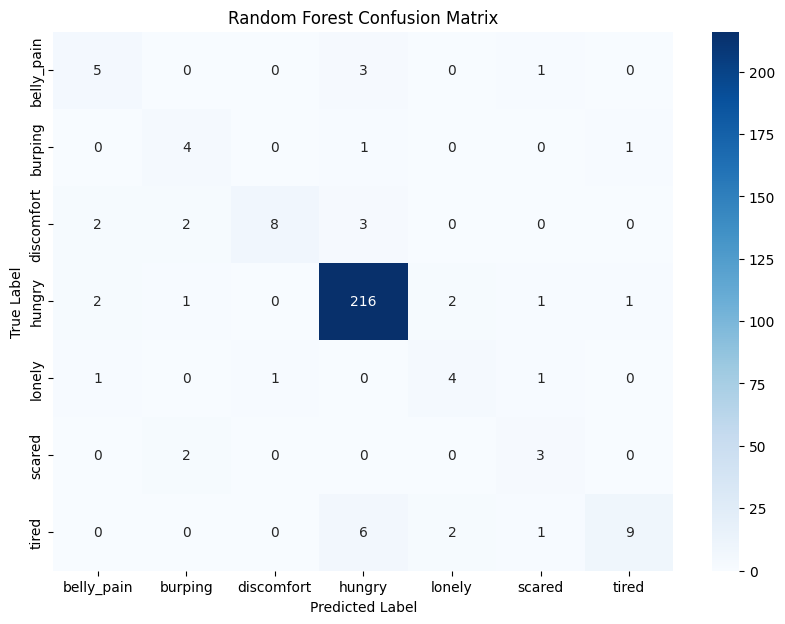

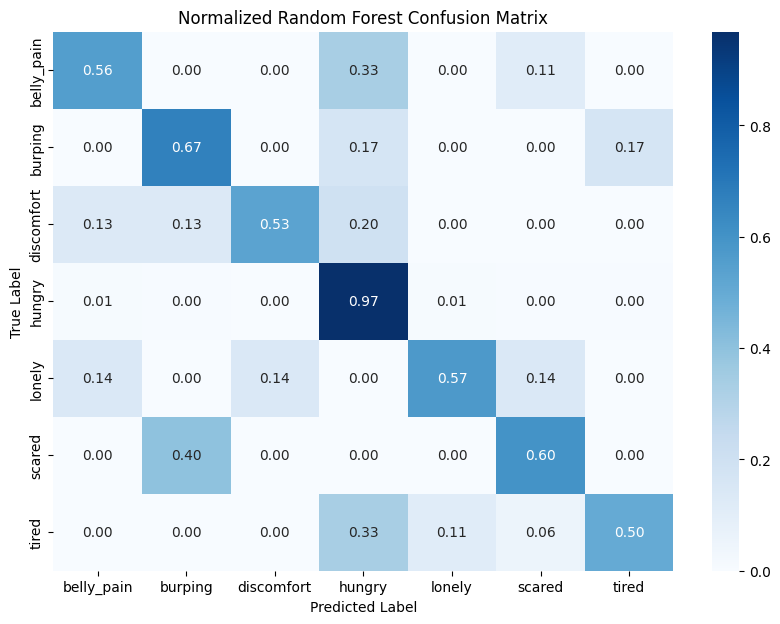

In [5]:
pipeline_rf = Pipeline([
    ("rf", RandomForestClassifier(
        n_estimators=200,
        criterion="gini",
        random_state=96
    ))
])

pipeline_rf.fit(x_train, y_train_encoder)
y_pred_rf = pipeline_rf.predict(x_test)

# ===== metrics =====
acc = accuracy_score(y_test_encoder, y_pred_rf)
f1_macro = f1_score(y_test_encoder, y_pred_rf, average="macro")
recall_macro = recall_score(y_test_encoder, y_pred_rf, average="macro")

print("=== Random Forest ===")
print(f"Accuracy     : {acc:.4f}")
print(f"F1 Macro     : {f1_macro:.4f}")
print(f"Recall Macro : {recall_macro:.4f}")
print()

print(classification_report(
    y_test_encoder,
    y_pred_rf,
    target_names=le.classes_
))

plot_confusion_matrix(
    y_test_encoder,
    y_pred_rf,
    le.classes_,
    title="Random Forest Confusion Matrix"
)

plot_confusion_matrix_normal(
    y_test_encoder,
    y_pred_rf,
    le.classes_,
    title="Normalized Random Forest Confusion Matrix"
)

KNN

=== KNN ===
Accuracy     : 0.6926
F1 Macro     : 0.4984
Recall Macro : 0.7210

              precision    recall  f1-score   support

  belly_pain       0.23      0.67      0.34         9
     burping       0.29      0.83      0.43         6
  discomfort       0.56      0.67      0.61        15
      hungry       0.98      0.68      0.80       223
      lonely       0.21      0.71      0.32         7
      scared       0.19      0.60      0.29         5
       tired       0.57      0.89      0.70        18

    accuracy                           0.69       283
   macro avg       0.43      0.72      0.50       283
weighted avg       0.86      0.69      0.74       283



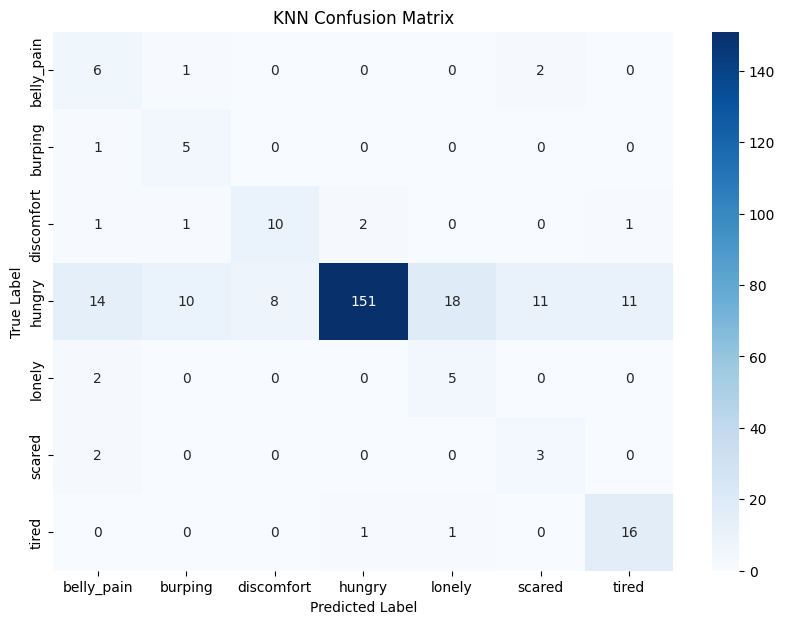

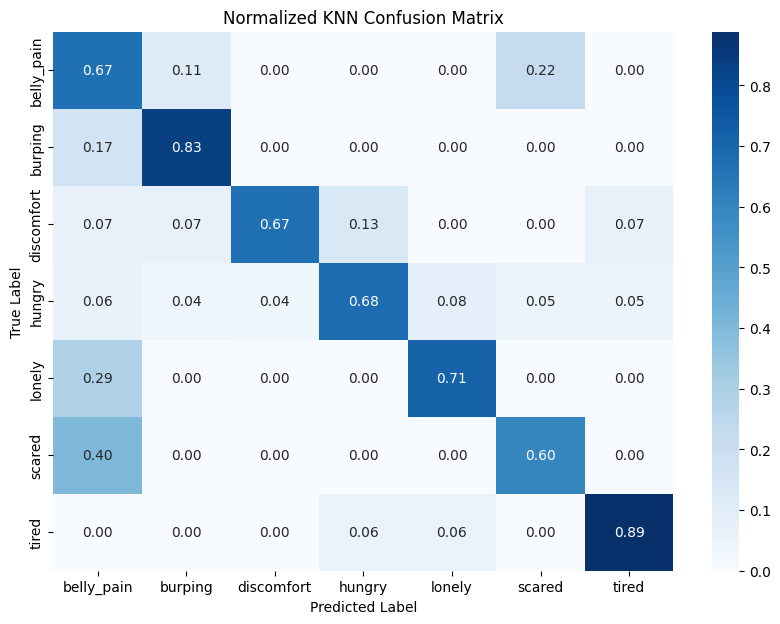

In [6]:
pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",
        metric="euclidean"
    ))
])

pipeline_knn.fit(x_train, y_train_encoder)
y_pred_knn = pipeline_knn.predict(x_test)

# ===== metrics =====
acc = accuracy_score(y_test_encoder, y_pred_knn)
f1_macro = f1_score(y_test_encoder, y_pred_knn, average="macro")
recall_macro = recall_score(y_test_encoder, y_pred_knn, average="macro")

print("=== KNN ===")
print(f"Accuracy     : {acc:.4f}")
print(f"F1 Macro     : {f1_macro:.4f}")
print(f"Recall Macro : {recall_macro:.4f}")
print()

print(classification_report(
    y_test_encoder,
    y_pred_knn,
    target_names=le.classes_
))

plot_confusion_matrix(
    y_test_encoder,
    y_pred_knn,
    le.classes_,
    title="KNN Confusion Matrix"
)

plot_confusion_matrix_normal(
    y_test_encoder,
    y_pred_knn,
    le.classes_,
    title="Normalized KNN Confusion Matrix"
)

XGBoost

=== XGBoost ===
Accuracy     : 0.8622
F1 Macro     : 0.6506
Recall Macro : 0.7307

              precision    recall  f1-score   support

  belly_pain       0.67      0.67      0.67         9
     burping       0.50      0.83      0.62         6
  discomfort       0.59      0.67      0.62        15
      hungry       0.97      0.91      0.94       223
      lonely       0.44      0.57      0.50         7
      scared       0.40      0.80      0.53         5
       tired       0.67      0.67      0.67        18

    accuracy                           0.86       283
   macro avg       0.60      0.73      0.65       283
weighted avg       0.89      0.86      0.87       283



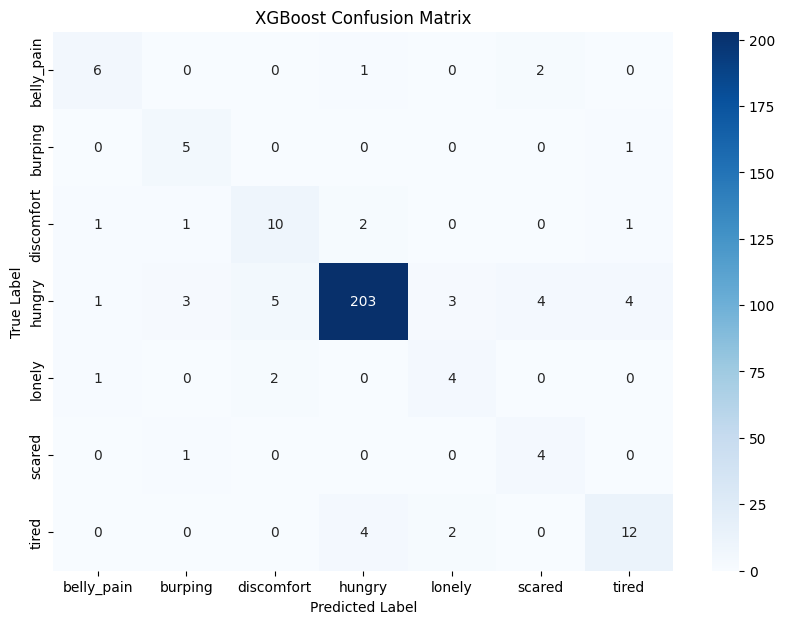

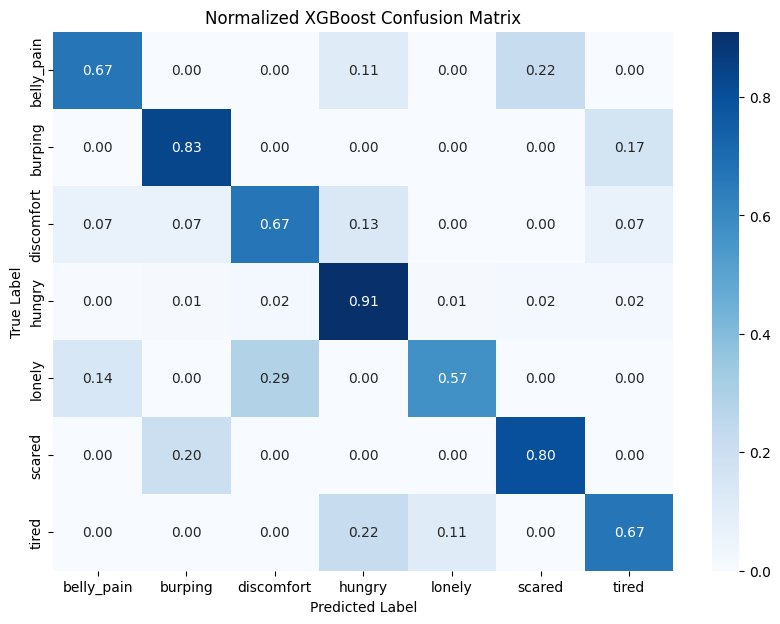

In [8]:
pipeline_xgb = Pipeline([
    ("xgb", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_estimators=100,
        max_depth=5,
        learning_rate=0.2,
        subsample=1,
        colsample_bytree=1,
        random_state=96
    ))
])

pipeline_xgb.fit(x_train, y_train_encoder)
y_pred_xgb = pipeline_xgb.predict(x_test)

# ===== metrics =====
acc = accuracy_score(y_test_encoder, y_pred_xgb)
f1_macro = f1_score(y_test_encoder, y_pred_xgb, average="macro")
recall_macro = recall_score(y_test_encoder, y_pred_xgb, average="macro")

print("=== XGBoost ===")
print(f"Accuracy     : {acc:.4f}")
print(f"F1 Macro     : {f1_macro:.4f}")
print(f"Recall Macro : {recall_macro:.4f}")
print()

print(classification_report(
    y_test_encoder,
    y_pred_xgb,
    target_names=le.classes_
))

plot_confusion_matrix(
    y_test_encoder,
    y_pred_xgb,
    le.classes_,
    title="XGBoost Confusion Matrix"
)

plot_confusion_matrix_normal(
    y_test_encoder,
    y_pred_xgb,
    le.classes_,
    title="Normalized XGBoost Confusion Matrix"
)

Logistic Regression

c:\Users\Hoannd\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Hoannd\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


=== Logistic Regression ===
Accuracy     : 0.5618
F1 Macro     : 0.2352
Recall Macro : 0.3054

              precision    recall  f1-score   support

  belly_pain       0.13      0.33      0.19         9
     burping       0.00      0.00      0.00         6
  discomfort       0.17      0.13      0.15        15
      hungry       0.83      0.65      0.73       223
      lonely       0.06      0.14      0.08         7
      scared       0.14      0.60      0.22         5
       tired       0.28      0.28      0.28        18

    accuracy                           0.56       283
   macro avg       0.23      0.31      0.24       283
weighted avg       0.69      0.56      0.61       283



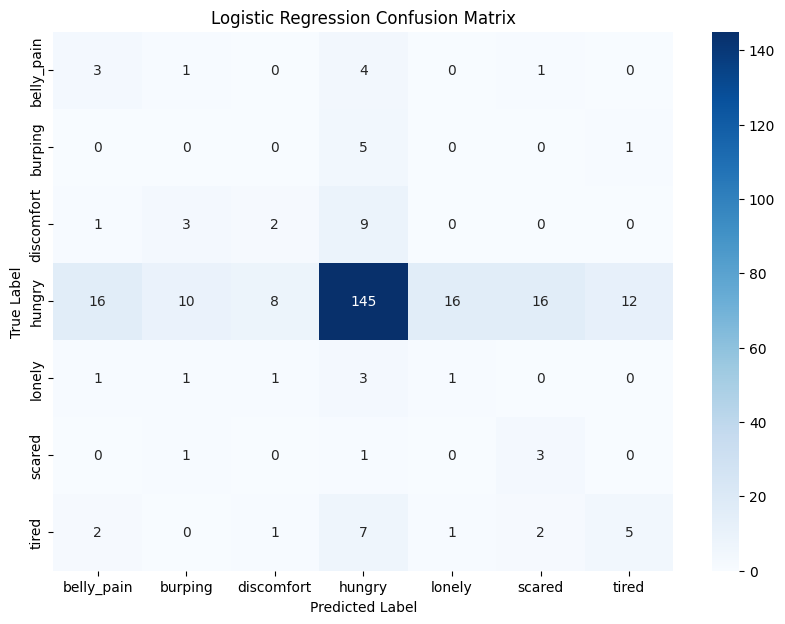

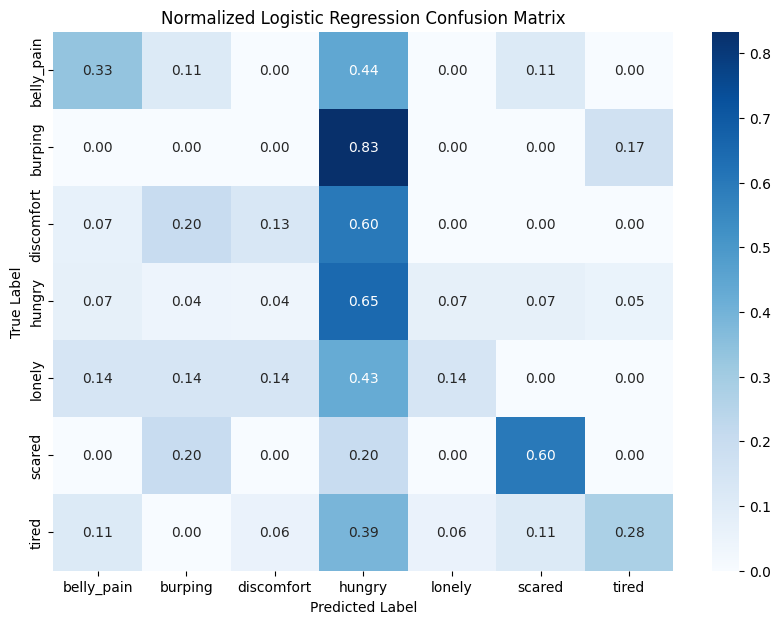

In [9]:
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=1000,
        penalty="l1",
        solver="saga"
    ))
])

pipeline_lr.fit(x_train, y_train_encoder)
y_pred_lr = pipeline_lr.predict(x_test)

# ===== metrics =====
acc = accuracy_score(y_test_encoder, y_pred_lr)
f1_macro = f1_score(y_test_encoder, y_pred_lr, average="macro")
recall_macro = recall_score(y_test_encoder, y_pred_lr, average="macro")

print("=== Logistic Regression ===")
print(f"Accuracy     : {acc:.4f}")
print(f"F1 Macro     : {f1_macro:.4f}")
print(f"Recall Macro : {recall_macro:.4f}")
print()

print(classification_report(
    y_test_encoder,
    y_pred_lr,
    target_names=le.classes_
))

plot_confusion_matrix(
    y_test_encoder,
    y_pred_lr,
    le.classes_,
    title="Logistic Regression Confusion Matrix"
)

plot_confusion_matrix_normal(
    y_test_encoder,
    y_pred_lr,
    le.classes_,
    title="Normalized Logistic Regression Confusion Matrix"
)